# **1. Project Overview**

## 1.1 Business Objective

The objective of this project is building machine learning models that can accurately predict housing prices based on property characteristics.
Accurate housing price predictions can support real estate agencies, buyers, sellers, and property investors in making informed decisions.
The model help find key factors influencing house prices and improve pricing consistency in the housing market.

## 1.2 Experiment Objective

The objective of this experiment is building a linear regression model to predict housing prices using the selected numerical and categorical features. This model will serve as the first predictive benchmark and it will be compared against the baseline model(Dummy Regressor).

## 1.3 Model Hypothesis

Linear Regression model is expected to outperform the dummy regressor because it can learn relationships between property characteristics and `SalePrice`. Based on the EDA, the selected features showed strong relationships with housing prcies. Therefore, this model is expected to achieve lower prediction errors and meaningful proportion of the variation in `SalePrice`.

# **2. Load Dataset**

In [1]:
import pandas as pd
import numpy as np

In [2]:
X_train = pd.read_csv('../data/X_train_processed.csv')
X_val = pd.read_csv('../data/X_val_processed.csv')
X_test = pd.read_csv('../data/X_test_processed.csv')

y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_val = pd.read_csv('../data/y_val.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

# **3. Model Development**

## 3.1 Import Algorithm

In [9]:
# Import LinearRegression from sklearn
from sklearn.linear_model import LinearRegression

## 3.2 Set Hyperparameters

In [10]:
linear = LinearRegression(fit_intercept=True)

## 3.3 Train Model

In [12]:
# Fit Model
linear.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 3.4 Generate Predictions

In [13]:
y_train_pred = linear.predict(X_train)
y_val_pred = linear.predict(X_val)
y_test_pred = linear.predict(X_test)

# **4. Model Evaluation**

## 4.1 Technical Performance

In [14]:
# Import RMSE, RAE, R2 score from sklearn
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import r2_score

In [21]:
# Check the Liner Regression performance
results = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'RMSE' : [
        rmse(y_train, y_train_pred),
        rmse(y_val, y_val_pred),
        rmse(y_test, y_test_pred)
    ],
    'MAE' : [
        mae(y_train, y_train_pred),
        mae(y_val, y_val_pred),
        mae(y_test, y_test_pred)
    ],
    'R2_Score' : [
        r2_score(y_train, y_train_pred),
        r2_score(y_val, y_val_pred),
        r2_score(y_test, y_test_pred)
    ]
})

results

,Dataset,RMSE,MAE,R2_Score
0,Train,0.149351,0.102497,0.861377
1,Validation,0.125409,0.091076,0.912541
2,Test,0.150586,0.107401,0.880767


## 4.2 Prediction Visualisation

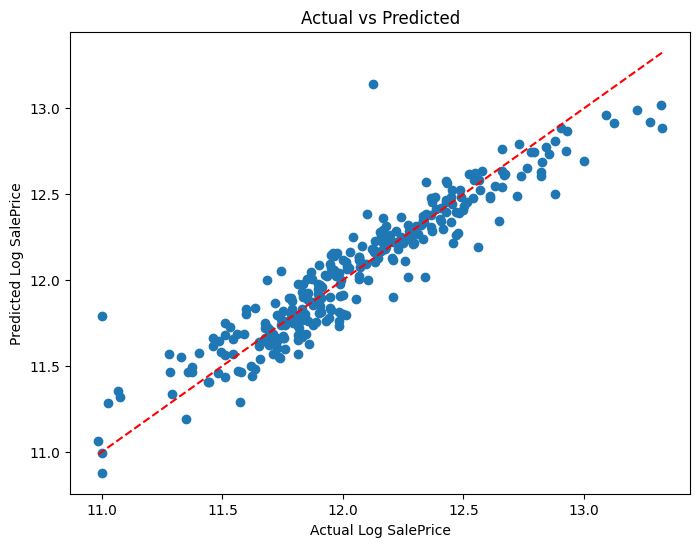

In [30]:
# Scatterplot of Actual Log SalePrice vs Predicted Log SalePrice
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual Log SalePrice')
plt.ylabel('Predicted Log SalePrice')
plt.title('Actual vs Predicted')

plt.show()

The predictive values closely follow the ideal prediction line(y=x). It shows that this Linear Regression model successfully captures the relationships between property characteristics and housing prices.
While there are some prediction errors, the overall pattern suggests strong predictive performance.


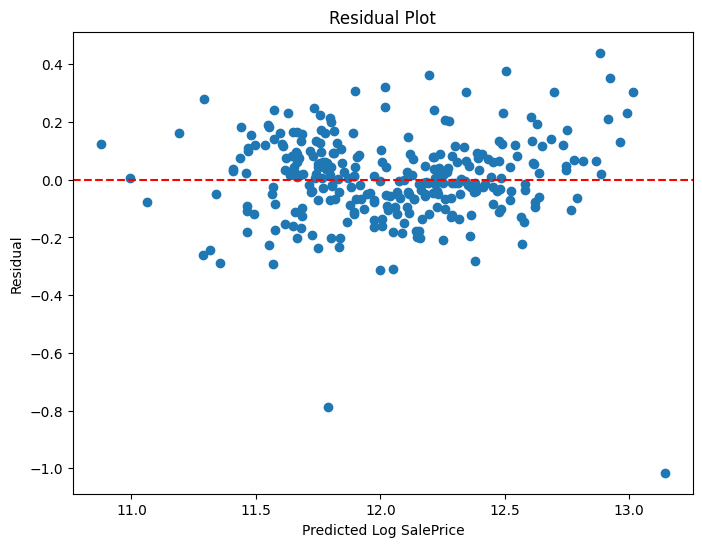

In [34]:
# Residual plot for the Linear Regression model
residuals = y_test - y_test_pred

plt.figure(figsize = (8,6))

plt.scatter(y_test_pred, residuals)

plt.axhline(color = 'r', ls = '--')

plt.xlabel('Predicted Log SalePrice')
plt.ylabel('Residual')
plt.title('Residual Plot')

plt.show()

The residuals are generally centred around zero and appear randomly distributed without a strong pattern. This suggests that the Linear Regression model captures most of the underlying relationships in the data. However, a few large residuals show that some properties are more difficult to predict accurately.

## 4.3 Model Interpretation

In [37]:
# Top 10 Positive Coefficients from the Linear Regression model
coefficient_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': linear.coef_
})

coefficient_df.sort_values(
    by = 'Coefficient',
    ascending = False
).head(10)

,Feature,Coefficient
22,nom__Neighborhood_GrnHill,0.502948
45,nom__MS Zoning_RL,0.189127
42,nom__MS Zoning_FV,0.167948
1,num__Gr Liv Area,0.129714
18,nom__Neighborhood_Crawfor,0.125332
46,nom__MS Zoning_RM,0.122527
4,num__Total Bsmt SF,0.120777
44,nom__MS Zoning_RH,0.120047
0,num__Overall Qual,0.107663
16,nom__Neighborhood_ClearCr,0.106608


In [39]:
# Top 10 Negative Coefficients from the Linear Regression model
coefficient_df.sort_values(
    by = 'Coefficient',
    ascending = True
).head(10)

,Feature,Coefficient
40,nom__MS Zoning_A (agr),-0.627374
14,nom__Neighborhood_BrDale,-0.185510
25,nom__Neighborhood_MeadowV,-0.114641
28,nom__Neighborhood_NPkVill,-0.109955
13,nom__Neighborhood_Blueste,-0.109202
12,nom__Neighborhood_Blmngtn,-0.101078
9,num__has_bsmt,-0.084993
24,nom__Neighborhood_Landmrk,-0.072279
32,nom__Neighborhood_OldTown,-0.067572
19,nom__Neighborhood_Edwards,-0.064476


## 4.4 Business Interpretation

- The Linear Regression model substantially outperformed the Dummy Regressor baseline. It achieved approximately 0.88 of R2 score on the test set. This indicates that the selected property characteristics contain meaningful information for predicting housing prices. 
- Features related to property quality, living area, basement size, and location were identified as important drivers of housing value. The results suggest that housing prices can be estimated with a relatively high degree of accuracy using a combination of structural, quality-related, and neighbourhood characteristics.

From a business perspective, the model could support real estate agencies, property investors, and home buyers by providing data-driven estimates of property values and highlighting the factors most strongly associated with market prices.

# **5. Experiment Outcomes**

## 5.1 Key Findings

- The Linear Regression model achieved strong predictive performance across the training, validation, and test datasets. R2 score for the test dataset(~0.88) indicates that a large proportion of variation in housing prices can be explained by the selected features. 
- Visual inspection of the Actual vs Predicted scatter plot showed that most predictions were closely aligned with the ideal prediction line. 
- The residual plot also suggested that prediction errors were generally centred around zero.

## 5.2 Hypothesis Evaluation

**The hypothesis was supported.** 
The experiment results also provide support for the broader EDA hypothesis that housing prices are influenced by factors related to property quality, size, and location. Features such as `Overall Qual`, `Gr Liv Area`, `Total Bsmt SF`, and several neighbourhood-related variables contributed meaningfully to the model's predictions, suggesting that these property characteristics are important drivers of housing value.


## 5.3 Limitations

- Linear Regression assumes a linear relationship between the input features and the target variable. It may not capture the complex interactions within the housing market.
- Some potentially relevant features were excluded during feature selection.
- This model may be affected by multicollinearity among highly related features such as `Garage Area` - `Garage Cars` and `1st Flr SF` - `Total Bsmt SF`. More advanced machine learning models may be able to capture non-linear ralationships and improve predictive performance.

## 5.4 Next Experiment

The next experiment will evaluate an ElasticNet Regression model. ElasticNet combines both L1 and L2 regularisation and may improve model generalisation by reducing the impact of multicollinearity and controlling model complexity. The performance of ElasticNet will be compared against the current Linear Regression model to determine whether regularisation provides additional predictive benefits.